# Points to pores - 2

***

In this notebook, we will look at how point distributions can be used to create porous media in 2D/3D by mapping points to networks. Output is a `PhaseDistribution` object.

#### <span style="color:red">Note: This is only currently implemented in 2D point distributions.</span>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tostada as tost

We first define point distribution that will serve at the template for the network. For simplicity, let us choose a quick Random Sequential Adsorption process.

In [ ]:
process = tost.Pointprocess(BoxSize=10,
                       diameter=0.3,
                       ax=0.5)
points = process.RandomSequentialAdsorption()

Estimated particles to be deposited=400 with mean inter-particle distance=0.5


number of experiments:5501300): |█-----------------------------| 5.5% Current FF=3.990 of 4.000


Now, the Voronoi network derived from the point distribution can be visualized using `scipy.spatial.Voronoi`.

In [28]:
from scipy.spatial import Voronoi,voronoi_plot_2d
vor = Voronoi(points.positions[:,:2])

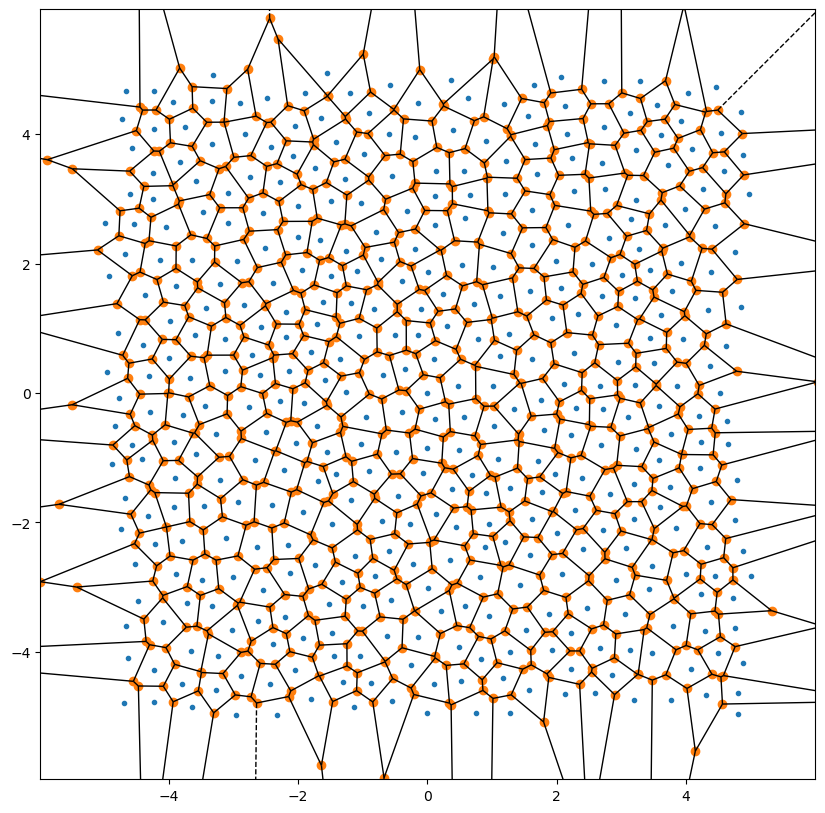

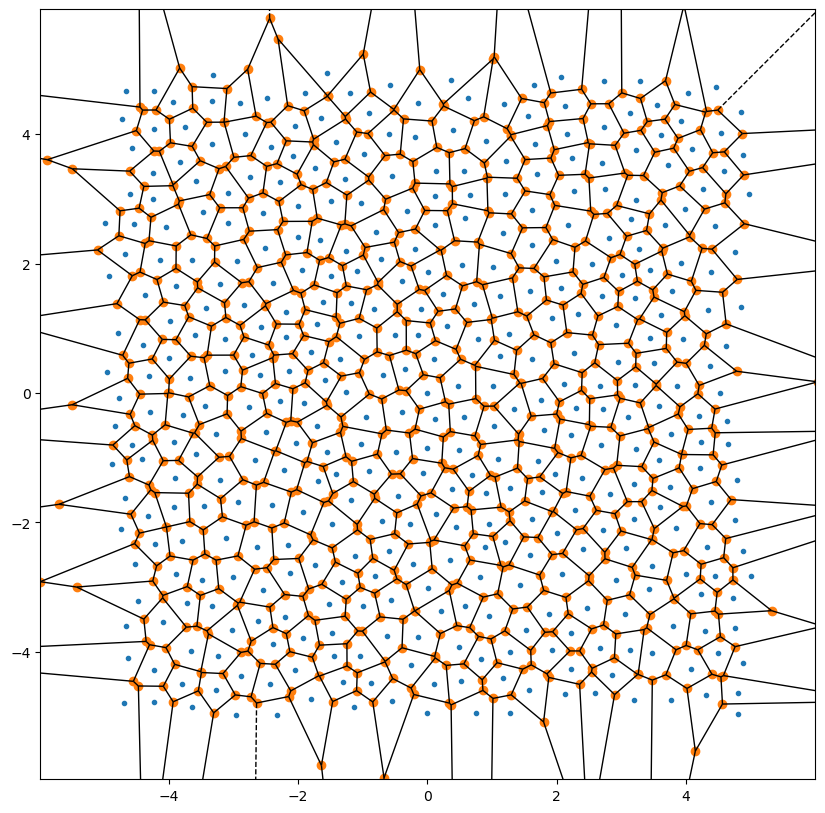

In [30]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)
voronoi_plot_2d(vor,ax=ax)

The solid lines (ridges) perpendicularly bisect the line connecting any two neighbouring RSA points. Note that, at the edges the lines meet at infinity. To avoid this, the points are first tessellated and then only the central unit-cell is chosen for dilation.

The phase distribution derived from such network can be accessed through `PointDistribution.Phaseobject_voronoi()`

In [31]:
X = points.Phaseobject_voronoi(resolution=0.01, #resolution in microns
                               rad=1) # radius by which dilation is performed

Volume fraction of generated phase = 0.034451


The `PhaseDistribution` obtained can be visualized through plotting tools from `tostada.plot_util.Visualize`

<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

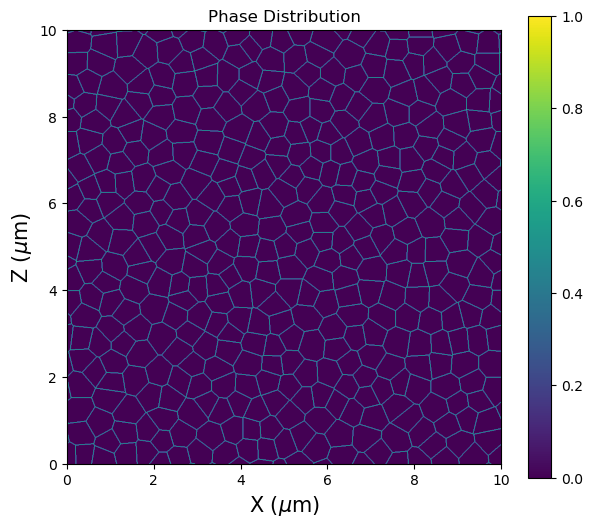

In [ ]:
fig = tost.Visualize(X)

fig.plot_distribution()

With `rad=1`, only a one-pixel network is obtained. The volume fraction here is proportional to the mean-interparticle distance chosen initially in the point-distribution.
Since the original point distribution is near-hyperuniform, we can check the reciprocal space properties of this phase distribution to see if the hyperuniformity is retained in such a network.

(1000, 1000) (1000, 1000)


[<Axes: title={'center': 'Reciprocal Space, Spectral density $\\tilde{X}(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{X}(|\\mathbf{q}|)$'>]

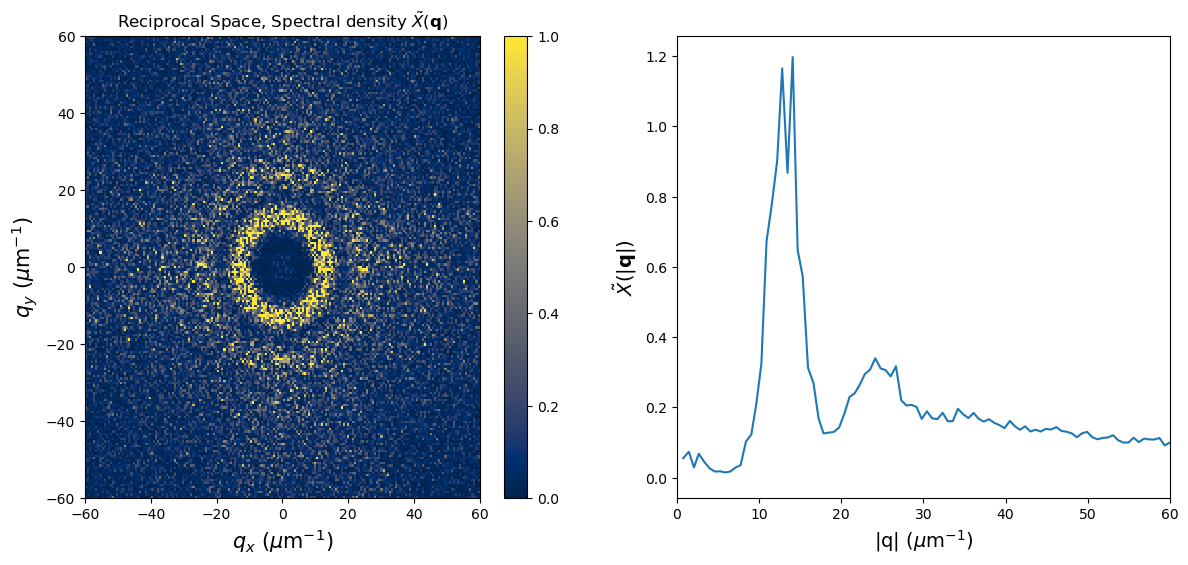

In [36]:
fig.plot_reciprocal_space(vmax=1)

It is evident that the hyperuniform features are inherited in such systems from the original point distributions. Also, absense of $X(q)$ peak for $q\rightarrow 0$ also suggests that the periodic-boundaries are satisfied. This can be verified with the method `PhaseDistribution.tesselate()`

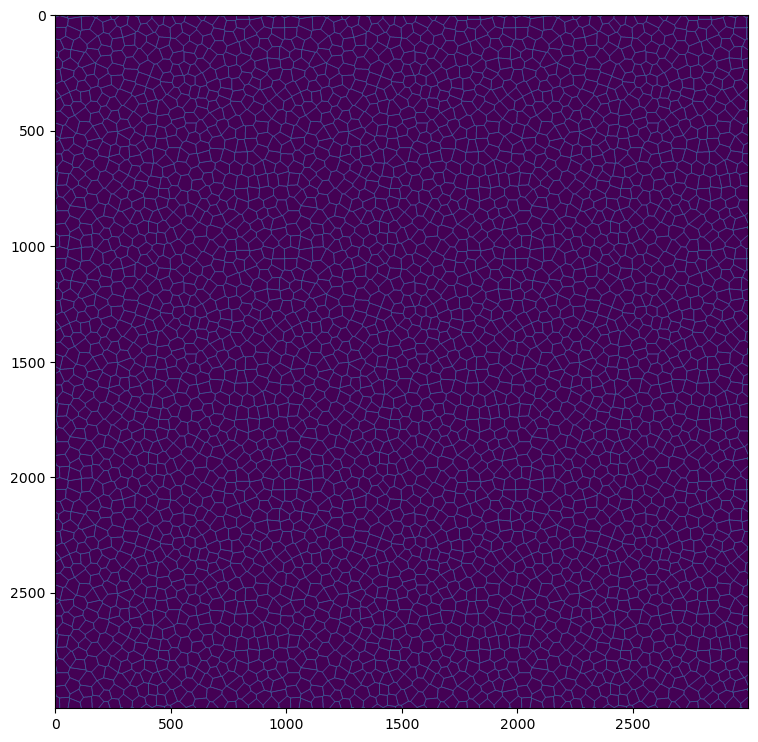

In [37]:
fig = plt.figure(figsize=(9,9))
plt.imshow(X.tesselate())

Clearly, there are no discontinuities in the network from the periodic tessellation.

The volume fraction of this network can be tuned by changing `rad` in the method.

In [40]:
X = points.Phaseobject_voronoi(resolution=0.01,rad=12)

Volume fraction of generated phase = 0.495993


<Axes: title={'center': 'Phase Distribution'}, xlabel='X ($\\mu$m)', ylabel='Z ($\\mu$m)'>

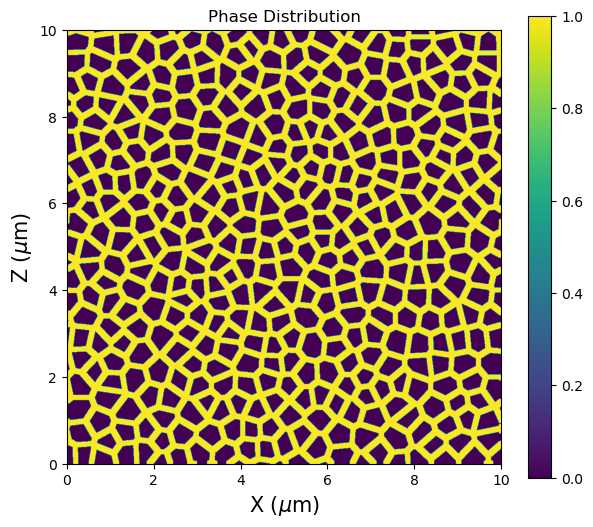

In [ ]:
fig = tost.Visualize(X)

fig.plot_distribution()

(1000, 1000) (1000, 1000)


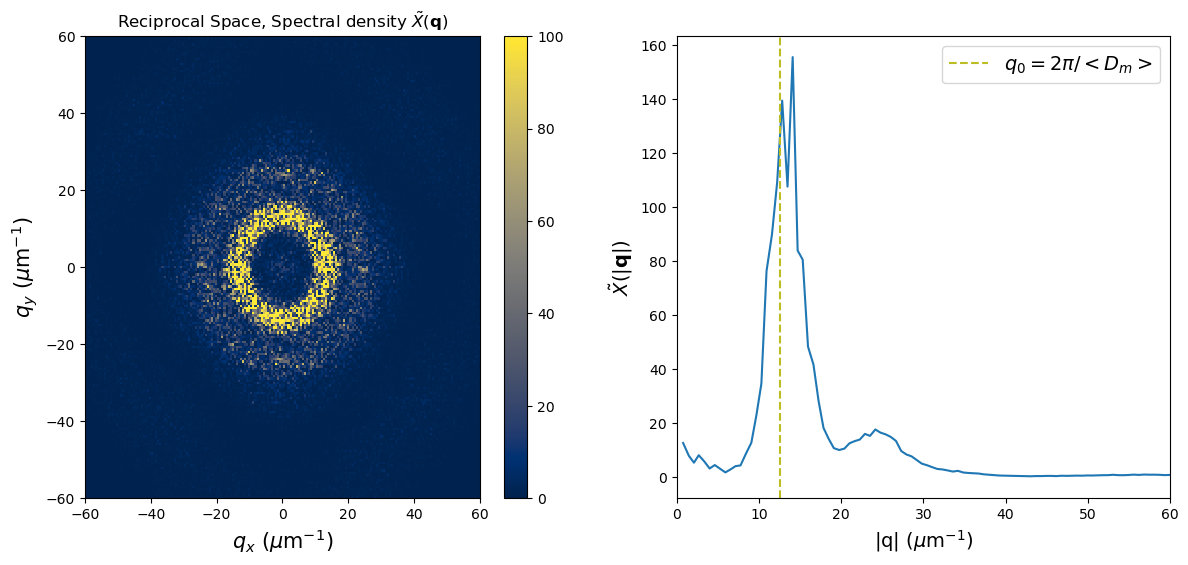

In [60]:
ax=fig.plot_reciprocal_space(vmax=100)
ax[1].axvline(x=2*np.pi/points.dmean,linestyle='--',color='tab:olive',label='$q_0=2\pi/<D_m>$')
ax[1].legend(fontsize=14)